# Hypothesis - Explore Additional Spotify Audio Features

Analyse extra Spotify audio features to see whether they provide any useful additional insights

- Select additional audio features
- Analyse their relationship with popularity
- Create visualisations if useful
- Record any meaningful findings

## Inputs

CSV file used:

spotifydataset_Visualisation.csv


## Outputs

Plots for testing validity of each hypothesis before considering visualisation


## Additional Comments

Developed an experimental ETL library which is in this project (modETL_library.py) 
Has lots of cool features so will be interesting to see how it works "in the field"

In [1]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import kruskal
#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from scipy.stats import spearmanr

#added by me for plotly.express visualisation issue
import nbformat 

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [2]:
#DataFrame variables for EDA
dfSpotify_DataSet_Work = None
dfSpotify_DataSet_Temp = None
dfSpotify_DataSet_Temp1 = None
dfSpotify_DataSet_Temp2 = None
dfSpotify_DataSet_Merged = None

#stores current directory
strCurrentDir = ""

#other vars
dictDataFrames = dict()
fig = None
axis = None


## Set Current Directory To Base Project Directory

In [3]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/sahraosman/Documents/vscode-projects/Spotify Music Trend Analysis


# Section 2

- Read csv file
- Look at hypothesis validity
- Use plot(s) to validate findings

## Read csv File Into Variable For Processing

In [4]:
#read csv file into DataFrame
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
dfSpotify_DataSet = dictDataFrames["spotifydataset_Visualisation.csv"]

#create copy of the original DataFrame to work with
dfSpotify_DataSet_Work = dfSpotify_DataSet.copy()

2 csv Files Read Into DataFrames

DataFrames Created:
spotifydataset_Visualisation.csv
spotify_dashboard_data.csv




# Analyse Extra Spotify Audio Features To See Whether They Provide Any Useful Additional Insights

# Compare Speechiness With Instrumentalness

Which is the more popular? Look at the top 100 highest records and compare

In [5]:
#which is more popular - songs with high levels of speechiness or instrumentalness?

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

#get highest speechiness value
print(f"Highest Speechiness Value: {dfSpotify_DataSet_Temp['speechiness'].max()}")
#get lowest speechiness value
print(f"Lowest Speechiness Value: {dfSpotify_DataSet_Temp['speechiness'].min()}")
print()

#now we have the range let us see what the top 100 records with highest popularity look like when sorted by speechiness
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","speechiness"]].sort_values(by="speechiness", ascending=False).head(100)

#show DataFrame
dfSpotify_DataSet_Temp1


Highest Speechiness Value: 0.965
Lowest Speechiness Value: 0.0



,popularity,speechiness
18152,26,0.965
18504,22,0.963
18530,23,0.963
18432,22,0.962
18227,25,0.962
...,...,...
18694,22,0.951
18159,25,0.951
18124,26,0.951
18284,24,0.951


# Observations

We can see that songs with the highest level of speechiness are quite unpopular (so much for audio books!) which is interesting

In [6]:
#which is more popular - songs with high levels of speechiness or instrumentalness?

#get records without duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")


#get highest instrumentalness value
print(f"Highest Instrumentalness Value: {dfSpotify_DataSet_Temp['instrumentalness'].max()}")
#get lowest instrumentalnessvalue
print(f"Lowest Instrumentalness Value: {dfSpotify_DataSet_Temp['instrumentalness'].min()}")
print()


#now we have the range let us see what the top 100 records with highest popularity look like when sorted by instrumentalness
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","instrumentalness"]].sort_values(by="instrumentalness", ascending=False).head(100)

#show DataFrame
dfSpotify_DataSet_Temp1


Highest Instrumentalness Value: 1.0
Lowest Instrumentalness Value: 0.0



,popularity,instrumentalness
101565,35,1.000
101724,33,1.000
101584,36,1.000
101375,85,1.000
101049,80,1.000
...,...,...
101439,37,0.991
101038,54,0.991
101554,36,0.991
101333,42,0.991


# Observations

Looks as thpugh high levels of instrumenalness have a detrimental effect on a songs popularity

# Get The Mean

Get the mean across *all* records to look for a generic value to compare with the top 100 records to check our assumption

In [7]:
#look at mean across all records
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","instrumentalness"]].sort_values(by="instrumentalness", ascending=False)

#get mean for popularity against high instrumentalness set alpha to default 5%
mean_popularity = dfSpotify_DataSet_Temp[dfSpotify_DataSet_Temp['instrumentalness'] > 0.5]['popularity'].mean()
print(f"Mean Popularity For Songs With High Instrumentalness: {mean_popularity}")


Mean Popularity For Songs With High Instrumentalness: 28.024315192470134


# Get The Mean

Get the mean across *top 100* records to look for a generic value to compare with the top 40 records as the results are unclear from the DataFrame alone

In [8]:
#now we have the range let us see what the top 40 records with highest popularity look like when sorted by instrumentalness
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","instrumentalness"]].sort_values(by="instrumentalness", ascending=False).head(100)

#get mean for popularity against high instrumentalness
mean_popularity = dfSpotify_DataSet_Temp[dfSpotify_DataSet_Temp['instrumentalness'] > 0.5]['popularity'].mean()
print(f"Mean Popularity For Songs With High Instrumentalness: {mean_popularity}")

Mean Popularity For Songs With High Instrumentalness: 28.024315192470134


# Observations

Wow! The mean is the same! This compared with the dataframe strongly suggests that high levels of instrumentalness are not popular, its a bad day for The Shadows!

# Plot Results

Lets plot speechiness against instrumentalness using their top 100 highest values

In [9]:
#plot speechiness against instrumentalness using their top 100 highest values

#speechiness

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

#now we have the range let us see what the top 40 records with highest popularity look like when sorted by speechiness
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","speechiness"]].sort_values(by="speechiness", ascending=False).head(100)


#instrumentalness

#get records without duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")


#now we have the range let us see what the top 40 records with highest popularity look like when sorted by instrumentalness
dfSpotify_DataSet_Temp2 = dfSpotify_DataSet_Temp[["popularity","instrumentalness"]].sort_values(by="instrumentalness", ascending=False).head(100)

#merge DataFrames
dfSpotify_DataSet_Merged = pd.merge(dfSpotify_DataSet_Temp1, dfSpotify_DataSet_Temp2, how='outer', left_index=True, right_index=True, 
                                    suffixes=('_speechiness', '_instrumentalness'))

#plot results
sns.histplot(data=dfSpotify_DataSet_Merged, x="popularity_speechiness", color="blue", label="Speechiness", kde=True, stat="density", alpha=0.5)
sns.histplot(data=dfSpotify_DataSet_Merged, x="popularity_instrumentalness", color="orange", label="Instrumentalness", kde=True, stat="density", alpha=0.5)
plt.title("Popularity Distribution For Speechiness vs Instrumentalness - Top 100 Records")
plt.xlabel("Popularity")
plt.ylabel("Density")
plt.legend()    
plt.show()

<Figure size 640x480 with 1 Axes>

# Observations

We can clearly see that songs with a lot of speech are clearly less popular then mostly instrumentals when analysing the top 100 records from each column

One clear insight we can gleen is that songs with a lot of speech or mostly just music are not as popular as less biased song types

# Compare Popularity With Time Signature

Are the most popular songs in a particular time signature?

In [10]:
#are the most popular songs in a particular time signature?

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

#now we have the range let us see what the top 100 records with highest popularity look like when sorted by instrumentalness
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","time_signature"]].sort_values(by="popularity", ascending=False).head(100)

#show DataFrame
dfSpotify_DataSet_Temp1

,popularity,time_signature
20001,100,4
51664,99,4
89410,98,4
81209,98,4
68303,97,4
...,...,...
31022,87,4
51402,87,4
20910,87,4
51216,87,4


# Observations

Brief look at the DataFrame strongly suggest 4/4 is the most common time signature in popular songs, lets confirm by putting it in a plot

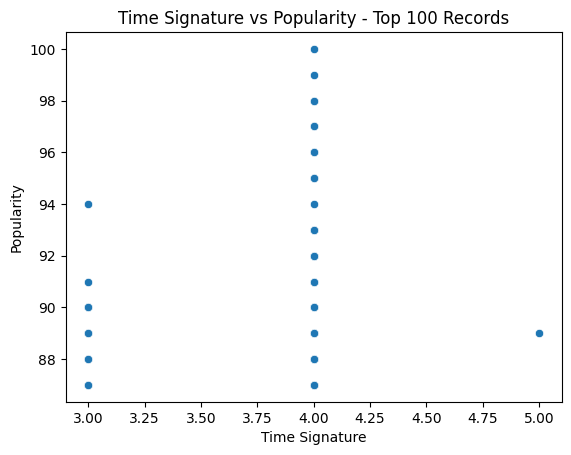

In [11]:
#plot time signature against popularity using their top 100 highest values

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

#get top 100 records with highest popularity and their time signature
dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","time_signature"]].sort_values(by="popularity", ascending=False).head(100)

sns.scatterplot(data=dfSpotify_DataSet_Temp1, x="time_signature", y="popularity")
plt.title("Time Signature vs Popularity - Top 100 Records")
plt.xlabel("Time Signature")
plt.ylabel("Popularity")
plt.show()

# Observations

4/4 is the clear winner with 3/4 a close second, not surprising as in the 17th-18th century waltzes were very popular and they are all in 3/4!

# Loook At Genre Of Top 100 Songs By Popularity

In [12]:
#check genre for top 100 most popular songs

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

dfSpotify_DataSet_Temp1 = dfSpotify_DataSet_Temp[["popularity","track_genre"]].sort_values(by="popularity", ascending=False).head(100)

fig = px.bar(dfSpotify_DataSet_Temp1, x="track_genre", y="popularity", color="track_genre", title="Genre Vs Popularity - Top 100 Records")
fig.update_layout(xaxis_title="Genre", yaxis_title="Popularity", height=800, width=1000, xaxis_tickangle=-90, legend_title="Genre")
fig.show()

# Observations

Pop is the clear winner, followed by latino and hip-hop which also featured in the top 20 most popular songs

# Look At Valance Against Popularity

Valance is the emotional quality of the song represented like IQR variance i.e. a float value from 0 to 1.0 interpreted thus:

1.0   - very positive emotional reaction  
0.5   - average emotional reaction  
< 0.5 - negative emotional reaction

In [13]:
#check valance against popularity for top 100 most popular songs

dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first").head(100)

dfSpotify_DataSet_Temp = dfSpotify_DataSet_Temp[["popularity","valence"]].sort_values(by="popularity", ascending=False)

#show results
dfSpotify_DataSet_Temp

,popularity,valence
20001,100,0.238
51664,99,0.550
89410,98,0.850
81209,98,0.304
68303,97,0.187
...,...,...
81022,87,0.168
51216,87,0.760
81663,87,0.270
3300,87,0.199


# Observations

No obvious correlation, time to put it in a plot!

In [14]:
#plot top 100 most popular songs against valance value
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first").head(100)

#sort by popularity
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Temp[["popularity","valence"]].sort_values(by="popularity", ascending=False)

#create plot
fig = px.scatter(dfSpotify_DataSet_Temp, x="valence", y="popularity", color="valence", title="Valence Vs Popularity - Top 100 Records")
fig.update_layout(xaxis_title="Valence", yaxis_title="Popularity", height=800, width=1000, legend_title="Valence")
fig.show()



# Observations

The lions share of the most popular songs fall below the alpha (0.5) which means emotionally darker songs are more popular to check lets look at the count of each

In [15]:
#get count of all records in top 100 most popular songs with valance less than 0.5
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first").head(100)

count = dfSpotify_DataSet_Temp[dfSpotify_DataSet_Temp["valence"] <=0.5].shape[0]
print(f"Count of all records in top 100 most popular songs with valance less than  0.5: {count}")

#get count of all records in the top 100 most popular songs with valance equal to 0.5
count = dfSpotify_DataSet_Temp[dfSpotify_DataSet_Temp["valence"] == 0.5].shape[0]
print(f"Count of all records in top 100 most popular songs with valance equal to 0.5: {count}")

#get count of all records in top 100 most popular songs with valance greater than 0.5
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first").head(100)

count = dfSpotify_DataSet_Temp[dfSpotify_DataSet_Temp["valence"] > 0.5].shape[0]
print(f"Count of all records in top 100 most popular songs with valance greater than 0.5: {count}")

Count of all records in top 100 most popular songs with valance less than  0.5: 62
Count of all records in top 100 most popular songs with valance equal to 0.5: 0
Count of all records in top 100 most popular songs with valance greater than 0.5: 38


# Observations

Assumption confirmed! People prefer less happy songs, question to ask (which is beyond the dataset to answer) is this finding seasonal?

# Look At Liveness Against Popularity For Top 100 Songs

Liveness is measured thus:  

Values above 0.8 indicate song performed live
Values below 8.0 indicate studio recording

In [16]:
#compare liveness with popularity

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

dfSpotify_DataSet_Temp = dfSpotify_DataSet_Temp[["popularity","liveness"]].sort_values(by="popularity", ascending=False).head(100)

#show results
dfSpotify_DataSet_Temp


,popularity,liveness
20001,100,0.2660
51664,99,0.2300
89410,98,0.2180
81209,98,0.3710
68303,97,0.1260
...,...,...
31022,87,0.2640
51402,87,0.3670
20910,87,0.3090
51216,87,0.0454


# Observations

Looks as though studio recording are the most popular, to double check lets put this data into a plot

In [17]:
#compare liveness with popularity

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

dfSpotify_DataSet_Temp = dfSpotify_DataSet_Temp[["popularity","liveness"]].sort_values(by="popularity", ascending=False).head(100)

fig = px.scatter(dfSpotify_DataSet_Temp, x="liveness", y="popularity", color="liveness", title="Liveness Vs Popularity - Top 100 Records")
fig.update_layout(xaxis_title="Genre", yaxis_title="Popularity", height=800, width=1000, xaxis_tickangle=-90, legend_title="Genre")
fig.show()

# Observations

Resounding conclusion more heavily studio produced songs are signifcantly more popular than live ones

# Look At Acousticness Against Popularity For Top 100 Songs

Acousticness is measured thus:

Values closer to 1 means song uses acoustic instruments
Values less than 0.8 means song uses less acoustic instruments


In [18]:
#compare liveness with popularity

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

dfSpotify_DataSet_Temp = dfSpotify_DataSet_Temp[["popularity","acousticness"]].sort_values(by="popularity", ascending=False).head(100)

#show results
dfSpotify_DataSet_Temp


,popularity,acousticness
20001,100,0.01300
51664,99,0.01250
89410,98,0.58300
81209,98,0.00383
68303,97,0.09930
...,...,...
31022,87,0.01850
51402,87,0.00524
20910,87,0.04900
51216,87,0.03020


# Observations

DataFrame strongly suggests less acoustic instrument songs are more popular, lets put this data into a plot

In [19]:
#compare acousticness with popularity

#get records wiithout duplicates
dfSpotify_DataSet_Temp = dfSpotify_DataSet_Work.sort_values(by="popularity", ascending=False).drop_duplicates(
    subset=["artists","album_name","track_name"], keep="first")

dfSpotify_DataSet_Temp = dfSpotify_DataSet_Temp[["popularity","acousticness"]].sort_values(by="popularity", ascending=False).head(100)

fig = px.scatter(dfSpotify_DataSet_Temp, x="acousticness", y="popularity", color="acousticness", title="Acousticness Vs Popularity - Top 100 Records")
fig.update_layout(xaxis_title="Acousticness", yaxis_title="Popularity", height=800, width=1000, xaxis_tickangle=-90, legend_title="Acousticness")
fig.show()


# Observations

Definately a huge swing in favour of less acoustic instruments with the core of the data being in the under 0.3 range implies digital music rather than actual instruments in the conventional sense